# 最高到達accuracyを取得する

In [1]:
from datetime import date

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
import json
import re
import sys
from collections import defaultdict

project_root = os.path.join(os.getcwd(), "..")
result_dir = os.path.join(project_root, "results")


def load_file_and_extract_max_accs(date, lr, target_concept_config_name, model_size, result_dir):
    """各initVecTypeとseedに対して、回したepochs中の最高到達accuracyを抽出する関数"""
    # if target_concept_config_type != '':
    #     target_concept_config_type = '-' + target_concept_config_type
    # dirname_pattern1 = f"gemma-3-{model_size}B-lr0.01{target_concept_config_type}-{date}-hidden_layer(-?\\d+)-seed(\\d+)_target_concepts_initvecwith(.*)"
    # dirname_pattern2 = f"gemma-3-{model_size}B-lr0.01{target_concept_config_type}-{date}-seed(\\d+)_target_concepts_initvecwith(.*)"

    target_concept_config_name = target_concept_config_name.replace('.json', '')
    dirname_pattern1 = f"gemma-3-{model_size}B-lr{lr}-{date}-hidden_layer(-?\\d+)-seed(\\d+)_{target_concept_config_name}_initvecwith(.*)"
    dirname_pattern2 = f"gemma-3-{model_size}B-lr{lr}-{date}-seed(\\d+)_{target_concept_config_name}_initvecwith(.*)"
    initVecType_to_seed_to_maxacc = defaultdict(dict)
    initVecType_to_seed_to_epoch_at_maxacc = defaultdict(dict)
    for dirname in os.listdir(result_dir):

        if re.match(dirname_pattern1, dirname):
            match_groups = re.search(dirname_pattern1, dirname)
            layer_idx = int(match_groups.group(1))
            seed = int(match_groups.group(2))
            initVecType = f"{match_groups.group(3)}_layer{layer_idx}"
        elif re.match(dirname_pattern2, dirname):
            match_groups = re.search(dirname_pattern2, dirname)
            print(match_groups)
            seed = int(match_groups.group(1))
            initVecType = match_groups.group(2)
        else:
            if date in dirname:
                # print(dirname)
                pass
            continue  # ディレクトリ名がどちらのパターンにもマッチしない場合はスキップ

        # print(f"Processing directory: {dirname}, initVecType: {initVecType}, seed: {seed}")
        
        if not os.path.exists(os.path.join(result_dir, dirname, 'logit_score_summary.json')):
            # print(f"Warning: logit_score_summary.json not found in {dirname}. Skipping.")
            continue
        with open(os.path.join(result_dir, dirname, 'logit_score_summary.json'), "r") as f:
            concept_to_epoch_to_scores = json.load(f)

        # 各conceptについて、回したepochs中の最高到達accuracyとそのepochを抽出
        max_accs = []
        epochs_at_maxacc = []
        for epoch_to_scores in concept_to_epoch_to_scores.values():
            max_accuracy = 0
            max_epoch_at_maxacc = 0
            for epoch, scores in epoch_to_scores.items():
                # print(f"Epoch: {epoch}, Accuracy: {scores['accuracy']}")
                if scores['accuracy'] > max_accuracy:
                    max_accuracy = scores['accuracy']
                    max_epoch_at_maxacc = epoch
            max_accs.append(max_accuracy)
            epochs_at_maxacc.append(max_epoch_at_maxacc)
        # print(f"Max Accuracies: {max_accs}")
        # print(f"Epochs at Max Accuracies: {epochs_at_maxacc}")
        initVecType_to_seed_to_maxacc[initVecType][seed] = max_accs
        initVecType_to_seed_to_epoch_at_maxacc[initVecType][seed] = epochs_at_maxacc
    return initVecType_to_seed_to_maxacc, initVecType_to_seed_to_epoch_at_maxacc


## 12B

In [2]:

date = '20260529'
model_size = '12'
lr = 0.003

target_concept_config_name = 'target_concepts_mini_13.json'


In [3]:

initVecType_to_seed_to_maxacc, initVecType_to_seed_to_epoch_at_maxacc = load_file_and_extract_max_accs(
    date, lr, target_concept_config_name, model_size, result_dir
)

seeds = set([seed for seed_to_maxacc in initVecType_to_seed_to_maxacc.values() for seed in seed_to_maxacc.keys()])
initVecType_lst = sorted(list(initVecType_to_seed_to_maxacc.keys()))

for seed in seeds:
    print(f"Seed: {seed}")
    for initVecType in initVecType_lst:
        max_accs = initVecType_to_seed_to_maxacc[initVecType].get(seed, None)
        if max_accs:
            mean_max_acc = np.mean(max_accs)
            std_max_acc = np.std(max_accs)
            print(f"\tInitVecType: {initVecType:15}, Seed: {seed}, Mean Max Accuracy: {mean_max_acc:.4f}, Std: {std_max_acc:.4f}")

print('\n' + '-' * 100 + '\n')

for seed in seeds:
    print(f"Seed: {seed}")
    for initVecType in initVecType_lst:
        epochs_at_maxacc = initVecType_to_seed_to_epoch_at_maxacc[initVecType].get(seed, None)

        if epochs_at_maxacc:
            mean_epoch_at_maxacc = np.mean([int(e) for e in epochs_at_maxacc])
            std_epoch_at_maxacc = np.std([int(e) for e in epochs_at_maxacc])
        print(f"\tInitVecType: {initVecType:15}, Seed: {seed}, Mean Epoch number at Max Accuracy: {mean_epoch_at_maxacc:.2f}, Std: {std_epoch_at_maxacc:.2f}")


<re.Match object; span=(0, 75), match='gemma-3-12B-lr0.003-20260529-seed13_target_concep>
<re.Match object; span=(0, 85), match='gemma-3-12B-lr0.003-20260529-seed3_target_concept>
<re.Match object; span=(0, 75), match='gemma-3-12B-lr0.003-20260529-seed18_target_concep>
<re.Match object; span=(0, 85), match='gemma-3-12B-lr0.003-20260529-seed5_target_concept>
<re.Match object; span=(0, 86), match='gemma-3-12B-lr0.003-20260529-seed13_target_concep>
<re.Match object; span=(0, 74), match='gemma-3-12B-lr0.003-20260529-seed8_target_concept>
<re.Match object; span=(0, 74), match='gemma-3-12B-lr0.003-20260529-seed2_target_concept>
<re.Match object; span=(0, 85), match='gemma-3-12B-lr0.003-20260529-seed9_target_concept>
<re.Match object; span=(0, 86), match='gemma-3-12B-lr0.003-20260529-seed11_target_concep>
<re.Match object; span=(0, 74), match='gemma-3-12B-lr0.003-20260529-seed7_target_concept>
<re.Match object; span=(0, 75), match='gemma-3-12B-lr0.003-20260529-seed14_target_concep>
<re.Match 

## epoch4固定でaccuracyを計算する

In [15]:
sys.path.append(project_root)

from utils.gemma_train_and_test_utils import calculate_metrics

def get_concept_to_epoch_score(concept_result_dir, epoch):
    concept_to_results = {}
    for dirname in os.listdir(concept_result_dir):
        if dirname.endswith(".json"):
            continue
        concept = dirname

        # このconceptに対するepochの結果を読み込む
        logit_score_path = os.path.join(concept_result_dir, dirname, f"logit-scored_epoch{epoch}.json")
        
        if not os.path.exists(logit_score_path):
            # raise FileNotFoundError(f"Logit score file not found: {logit_score_path}")
            # print(f"Logit score file not found: {logit_score_path}. Skipping this concept.")
            continue
        
        try:
            with open(logit_score_path, 'r') as f:
                results = json.load(f)
        except Exception as e:
            raise(f"Error loading logit score file: {dirname}. Skipping this concept. Error: {e}")
            
        y_true_lst = [res['label'] for res in results]
        y_pred_lst = [res['pred'] for res in results]

        # score計算
        metrics = calculate_metrics(y_pred_lst, y_true_lst)

        concept_to_results[concept] = metrics

        # print(f"  Epoch {epoch}: Accuracy: {metrics['accuracy']:.4f}, Precision: {metrics['precision']:.4f}, Recall: {metrics['recall']:.4f}, F1: {metrics['F1']:.4f}")
    
    return concept_to_results





def load_file_and_calc_epoch_accs(date, epoch, lr, target_concept_config_name, model_size, result_dir, print_flag=False):
    """各initVecTypeとseedに対して、回したepochs中の最高到達accuracyを抽出する関数"""

    target_concept_config_name = target_concept_config_name.replace('.json', '')
    dirname_pattern1 = f"gemma-3-{model_size}B-lr{lr}-{date}-hidden_layer(-?\\d+)-seed(\\d+)_{target_concept_config_name}_initvecwith(.*)"
    dirname_pattern2 = f"gemma-3-{model_size}B-lr{lr}-{date}-seed(\\d+)_{target_concept_config_name}_initvecwith(.*)"

    initvectype_to_seed_to_acc = defaultdict(dict)
    for dirname in os.listdir(result_dir):
        p1_match = re.match(dirname_pattern1, dirname)
        p2_match = re.match(dirname_pattern2, dirname)

        if p1_match: #re.match(dirname_pattern1, dirname):
            match_groups = re.search(dirname_pattern1, dirname)
            layer_idx = int(match_groups.group(1))
            seed = int(match_groups.group(2))
            initVecType = f"{match_groups.group(3)}_layer{layer_idx}"
        elif p2_match: # re.match(dirname_pattern2, dirname):
            match_groups = re.search(dirname_pattern2, dirname)
            # print(match_groups)
            seed = int(match_groups.group(1))
            initVecType = match_groups.group(2)
        else:
            if date in dirname:
                pass
            continue  # ディレクトリ名がどちらのパターンにもマッチしない場合はスキップ

        concept_to_results = get_concept_to_epoch_score(os.path.join(result_dir, dirname), epoch)
        if len(concept_to_results) == 0:
            # print(f"No valid concepts with logit score files found for directory: {dirname}. Skipping.")
            continue
        sum_acc = 0
        for concept, score in concept_to_results.items():
            acc = score['accuracy']
            sum_acc += acc

        avg_acc = sum_acc / len(concept_to_results)
        initvectype_to_seed_to_acc[initVecType][seed] = avg_acc
        if print_flag:
            print(f"InitVecType: {initVecType}, Seed: {seed}, Average Accuracy at Epoch {epoch}: {avg_acc:.4f}")

    return initvectype_to_seed_to_acc


In [5]:
layer = 12
seed_num = 20
max_epoch = 10

cat_mean_accs, cat_std_accs = [], []
nearcat_mean_accs, nearcat_std_accs = [], []
farcat_mean_accs, farcat_std_accs = [], []
zero_mean_accs, zero_std_accs = [], []
norm_rand_vocab_mean_accs, norm_rand_vocab_std_accs = [], []

for epoch in range(0, max_epoch+1):
    print(f"Epoch: {epoch}")


    # date = '20260427'
    
    initvectype_to_seed_to_acc = load_file_and_calc_epoch_accs(date, epoch, lr=lr, 
                                                            target_concept_config_name=target_concept_config_name, 
                                                            model_size=model_size, 
                                                            result_dir=result_dir,
                                                            print_flag=False)

    # ** Cat **
    initVecType = f'CatCent_by_WikiSummaryRepeatHSMixed_layer{layer}'
    print(f"InitVecType: {initVecType}")
    acc_lst = []
    for seed in range(seed_num):
        seed_to_acc = initvectype_to_seed_to_acc.get(initVecType, {})
        acc = seed_to_acc.get(seed, None)
        if acc is not None:
            acc_lst.append(acc)
            print(f"InitVecType: {initVecType}, Seed: {seed}, Average Accuracy at Epoch {epoch}: {acc:.4f}")
        else:
            # print(f"\tInitVecType: {initVecType}, No data for Seed {seed}")
            pass
    print('\t', acc_lst)
        
    # mean ± std
    mean = np.mean(acc_lst)
    std = np.std(acc_lst)
    print(f"\taccuracy at epoch {epoch}: {mean:.4f} ± {std:.4f}")
    print()
    cat_acc_lst = acc_lst
    cat_mean_accs.append(mean)
    cat_std_accs.append(std)


    # ** nearCat ** [WIP] nearのみwikisummaryのrepeatを入れ忘れていたため現在再実験中。終わったらここもコメントアウトを外す -> 終わった
    initVecType = f'nearCatCent_by_WikiSummaryRepeatHSMixed_layer{layer}'
    print(f"InitVecType: {initVecType}")
    acc_lst = []
    for seed in range(seed_num): 
        seed_to_acc = initvectype_to_seed_to_acc.get(initVecType, {})
        acc = seed_to_acc.get(seed, None)
        if acc is not None:
            acc_lst.append(acc)
            print(f"\tInitVecType: {initVecType}, Seed: {seed}, Average Accuracy at Epoch {epoch}: {acc:.4f}")
        else:
            # print(f"\tInitVecType: {initVecType}, No data for Seed {seed}")
            pass
    print('\t', acc_lst)
        
    # mean ± std
    mean = np.mean(acc_lst)
    std = np.std(acc_lst)
    print(f"\taccuracy at epoch {epoch}: {mean:.4f} ± {std:.4f}")
    print()
    nearcat_acc_lst = acc_lst
    nearcat_mean_accs.append(mean)
    nearcat_std_accs.append(std)



    # ** farCat ** [WIP] 4/27より後の実験はother -> farとしているため適宜ここも修正する
    initVecType = f'farCatCent_by_WikiSummaryRepeatHSMixed_layer{layer}'
    print(f"InitVecType: {initVecType}")
    acc_lst = []
    for seed in range(seed_num):
        seed_to_acc = initvectype_to_seed_to_acc.get(initVecType, {})
        acc = seed_to_acc.get(seed, None)
        if acc is not None:
            acc_lst.append(acc)
            print(f"\tInitVecType: {initVecType}, Seed: {seed}, Average Accuracy at Epoch {epoch}: {acc:.4f}")
        else:
            # print(f"\tInitVecType: {initVecType}, No data for Seed {seed}")
            pass
    print('\t', acc_lst)
    
    # mean ± std
    mean = np.mean(acc_lst)
    std = np.std(acc_lst)
    print(f"\taccuracy at epoch {epoch}: {mean:.4f} ± {std:.4f}")
    print()
    farcat_acc_lst = acc_lst
    farcat_mean_accs.append(mean)
    farcat_std_accs.append(std)


    # ** norm_rand_vocab **
    initVecType = 'norm_rand_vocab'
    print(f"InitVecType: {initVecType}")
    acc_lst = []
    for seed in range(seed_num):
        seed_to_acc = initvectype_to_seed_to_acc.get(initVecType, {})
        acc = seed_to_acc.get(seed, None)
        if acc is not None:
            acc_lst.append(acc)
            print(f"\tInitVecType: {initVecType}, Seed: {seed}, Average Accuracy at Epoch {epoch}: {acc:.4f}")
        else:
            # print(f"\tInitVecType: {initVecType}, No data for Seed {seed}")
            pass
    print('\t', acc_lst)

    # mean ± std
    mean = np.mean(acc_lst)
    std = np.std(acc_lst)
    print(f"\taccuracy at epoch {epoch}: {mean:.4f} ± {std:.4f}")
    print()
    norm_rand_vocab_acc_lst = acc_lst
    norm_rand_vocab_mean_accs.append(mean)
    norm_rand_vocab_std_accs.append(std)



    # ** zero **
    initVecType = 'zero'
    print(f"InitVecType: {initVecType}")
    acc_lst = []
    for seed in range(seed_num):
        seed_to_acc = initvectype_to_seed_to_acc.get(initVecType, {})
        acc = seed_to_acc.get(seed, None)
        if acc is not None:
            acc_lst.append(acc)
            print(f"\tInitVecType: {initVecType}, Seed: {seed}, Average Accuracy at Epoch {epoch}: {acc:.4f}")
        else:
            # print(f"\tInitVecType: {initVecType}, No data for Seed {seed}")
            pass
    print('\t', acc_lst)

    # mean ± std
    mean = np.mean(acc_lst)
    std = np.std(acc_lst)
    print(f"\taccuracy at epoch {epoch}: {mean:.4f} ± {std:.4f}")
    zero_acc_lst = acc_lst
    zero_mean_accs.append(mean)
    zero_std_accs.append(std)

    print('\n==============================\n==============================\n')
    

# どの日付のモデルが読み込まれたのかの確認用
print(f"date: {date}")


Epoch: 0
<re.Match object; span=(0, 75), match='gemma-3-12B-lr0.003-20260529-seed13_target_concep>
<re.Match object; span=(0, 85), match='gemma-3-12B-lr0.003-20260529-seed3_target_concept>
<re.Match object; span=(0, 75), match='gemma-3-12B-lr0.003-20260529-seed18_target_concep>
<re.Match object; span=(0, 85), match='gemma-3-12B-lr0.003-20260529-seed5_target_concept>
<re.Match object; span=(0, 86), match='gemma-3-12B-lr0.003-20260529-seed13_target_concep>
<re.Match object; span=(0, 74), match='gemma-3-12B-lr0.003-20260529-seed8_target_concept>
<re.Match object; span=(0, 74), match='gemma-3-12B-lr0.003-20260529-seed2_target_concept>
<re.Match object; span=(0, 85), match='gemma-3-12B-lr0.003-20260529-seed9_target_concept>
<re.Match object; span=(0, 86), match='gemma-3-12B-lr0.003-20260529-seed11_target_concep>
<re.Match object; span=(0, 74), match='gemma-3-12B-lr0.003-20260529-seed7_target_concept>
<re.Match object; span=(0, 75), match='gemma-3-12B-lr0.003-20260529-seed14_target_concep>
<

In [6]:
print(cat_mean_accs)
# print(cat_std_accs)

print(nearcat_mean_accs)
# print(nearcat_std_accs)

print(farcat_mean_accs)
# print(farcat_std_accs)

print(norm_rand_vocab_mean_accs)
# print(norm_rand_vocab_std_accs)

print(zero_mean_accs)
# print(zero_std_accs)


[np.float64(0.4024050347064449), np.float64(0.576823391786635), np.float64(0.6372423916870174), np.float64(0.6615599037349953), np.float64(0.6779324661578581), np.float64(0.6844249194498462), np.float64(0.6903237972636094), np.float64(0.6942502356771476), np.float64(0.7004615221026211), np.float64(0.7038312549660886), np.float64(0.6998778425007327)]
[np.float64(0.40379510245207023), np.float64(0.5688882160397543), np.float64(0.6261092507526903), np.float64(0.655800741774691), np.float64(0.6633518647098329), np.float64(0.6743623749646804), np.float64(0.6795265503286332), np.float64(0.6844426661439578), np.float64(0.6876091142976806), np.float64(0.6898884819367892), np.float64(0.6858268977119361)]
[np.float64(0.40783144303296065), np.float64(0.5681431032317834), np.float64(0.6238334173760005), np.float64(0.6570800663013799), np.float64(0.6692299520368342), np.float64(0.6787089636379535), np.float64(0.68182987180244), np.float64(0.691351961763669), np.float64(0.6898461425947917), np.float

In [7]:
for epoch in range(0, max_epoch+1):
    print(f"Epoch {epoch}:")
    print(f"  CatCent: {cat_mean_accs[epoch]:.4f} ± {cat_std_accs[epoch]:.4f}")
    print(f"  nearCatCent: {nearcat_mean_accs[epoch]:.4f} ± {nearcat_std_accs[epoch]:.4f}")
    print(f"  farCatCent: {farcat_mean_accs[epoch]:.4f} ± {farcat_std_accs[epoch]:.4f}")
    print(f"  norm_rand_vocab: {norm_rand_vocab_mean_accs[epoch]:.4f} ± {norm_rand_vocab_std_accs[epoch]:.4f}")
    print(f"  zero: {zero_mean_accs[epoch]:.4f} ± {zero_std_accs[epoch]:.4f}")
    print()

Epoch 0:
  CatCent: 0.4024 ± 0.0020
  nearCatCent: 0.4038 ± 0.0024
  farCatCent: 0.4078 ± 0.0022
  norm_rand_vocab: 0.4023 ± 0.0000
  zero: 0.4080 ± 0.0000

Epoch 1:
  CatCent: 0.5768 ± 0.0280
  nearCatCent: 0.5689 ± 0.0237
  farCatCent: 0.5681 ± 0.0192
  norm_rand_vocab: 0.5351 ± 0.0257
  zero: 0.4942 ± 0.0250

Epoch 2:
  CatCent: 0.6372 ± 0.0252
  nearCatCent: 0.6261 ± 0.0230
  farCatCent: 0.6238 ± 0.0168
  norm_rand_vocab: 0.6022 ± 0.0271
  zero: 0.5456 ± 0.0282

Epoch 3:
  CatCent: 0.6616 ± 0.0275
  nearCatCent: 0.6558 ± 0.0231
  farCatCent: 0.6571 ± 0.0230
  norm_rand_vocab: 0.6266 ± 0.0249
  zero: 0.5699 ± 0.0251

Epoch 4:
  CatCent: 0.6779 ± 0.0234
  nearCatCent: 0.6634 ± 0.0220
  farCatCent: 0.6692 ± 0.0217
  norm_rand_vocab: 0.6395 ± 0.0237
  zero: 0.5988 ± 0.0278

Epoch 5:
  CatCent: 0.6844 ± 0.0207
  nearCatCent: 0.6744 ± 0.0221
  farCatCent: 0.6787 ± 0.0223
  norm_rand_vocab: 0.6549 ± 0.0262
  zero: 0.6219 ± 0.0304

Epoch 6:
  CatCent: 0.6903 ± 0.0227
  nearCatCent: 0.6795 

### Paired-t-test, Wilcoxon 

In [13]:
import numpy as np
from scipy import stats

layer = 12
seed_num = 20
max_epoch = 10

#### CatCent - farCatCentの差の有意性検定

In [18]:




for epoch in range(0, max_epoch+1):
    print(f"Epoch: {epoch}")

    initvectype_to_seed_to_acc = load_file_and_calc_epoch_accs(date, epoch, lr=lr, 
                                                            target_concept_config_name=target_concept_config_name, 
                                                            model_size=model_size, 
                                                            result_dir=result_dir,
                                                            print_flag=False)

    # ** Cat **
    initVecType = f'CatCent_by_WikiSummaryRepeatHSMixed_layer{layer}'
    # print(f"InitVecType: {initVecType}")
    acc_lst = []
    for seed in range(seed_num):
        seed_to_acc = initvectype_to_seed_to_acc.get(initVecType, {})
        acc = seed_to_acc.get(seed, None)
        if acc is not None:
            acc_lst.append(acc)
            # print(f"InitVecType: {initVecType}, Seed: {seed}, Average Accuracy at Epoch {epoch}: {acc:.4f}")
        else:
            # print(f"\tInitVecType: {initVecType}, No data for Seed {seed}")
            pass
    print('\t', acc_lst)
    catcent_accs = np.array(acc_lst)
    

    # ** farCat ** [WIP] 4/27より後の実験はother -> farとしているため適宜ここも修正する
    initVecType = f'farCatCent_by_WikiSummaryRepeatHSMixed_layer{layer}'
    # print(f"InitVecType: {initVecType}")
    acc_lst = []
    for seed in range(seed_num):
        seed_to_acc = initvectype_to_seed_to_acc.get(initVecType, {})
        acc = seed_to_acc.get(seed, None)
        if acc is not None:
            acc_lst.append(acc)
            # print(f"\tInitVecType: {initVecType}, Seed: {seed}, Average Accuracy at Epoch {epoch}: {acc:.4f}")
        else:
            # print(f"\tInitVecType: {initVecType}, No data for Seed {seed}")
            pass
    print('\t', acc_lst)
    farcat_accs = np.array(acc_lst)


    diff = catcent_accs - farcat_accs

    # paired t-test
    t_stat, p_value = stats.ttest_rel(catcent_accs, farcat_accs)

    # Wilcoxon signed-rank test
    w_stat, p_wilcoxon = stats.wilcoxon(catcent_accs, farcat_accs)

    print("mean diff:", diff.mean())
    print("std diff:", diff.std(ddof=1))
    print("paired t-test p:", p_value)
    print("wilcoxon p:", p_wilcoxon)


    print('\n==============================\n==============================\n')
    

# どの日付のモデルが読み込まれたのかの確認用
print(f"date: {date}")


Epoch: 0
	 [0.40348249218601234, 0.404493059285288, 0.40119320299677674, 0.4032429414790388, 0.4022959421961636, 0.40431537647379034, 0.40266808708383994, 0.4031128278988025, 0.40211560250175743, 0.40176821491128345, 0.4021123486272951, 0.4049134565767742, 0.4010409623193421, 0.4002803385447865, 0.4036967414928658, 0.39747078855428924, 0.4006110547978793, 0.40108234333880055, 0.40080645354974087, 0.4073984593143712]
	 [0.4084080856379232, 0.4080785589407857, 0.40767725956208484, 0.4038182885763112, 0.41085722199846136, 0.40902250839445975, 0.4068835954160472, 0.40893168527374546, 0.40973757332477057, 0.4094850008692069, 0.4095961953291128, 0.41044961678168435, 0.40747749759728075, 0.4084960746868879, 0.40363407096874765, 0.4048392823333111, 0.40895373403888474, 0.4046153982089401, 0.41066486731875096, 0.40500234540181673]
mean diff: -0.0054264083265157664
std diff: 0.0031638917477499577
paired t-test p: 3.114095283242607e-07
wilcoxon p: 1.33514404296875e-05


Epoch: 1
	 [0.554075827473

### graph

In [8]:
import matplotlib.pyplot as plt
import japanize_matplotlib


cat_mean_accs = np.array(cat_mean_accs)
cat_std_accs = np.array(cat_std_accs)
nearcat_mean_accs = np.array(nearcat_mean_accs)
nearcat_std_accs = np.array(nearcat_std_accs)
farcat_mean_accs = np.array(farcat_mean_accs)
farcat_std_accs = np.array(farcat_std_accs)
zero_mean_accs = np.array(zero_mean_accs)
zero_std_accs = np.array(zero_std_accs)
norm_rand_vocab_mean_accs = np.array(norm_rand_vocab_mean_accs)
norm_rand_vocab_std_accs = np.array(norm_rand_vocab_std_accs)


epochs = list(range(0, max_epoch+1))

colors = {
    "同カテゴリ初期化": "tab:blue",
    "近カテゴリ初期化": "skyblue",
    "遠カテゴリ初期化": "tab:green",
    "ノルムランダム語彙初期化": "orange", #"black",
    "ゼロ初期化": "red" #"gray"
}
# ["tab:blue", "skyblue", "tab:green", "black", "gray"]



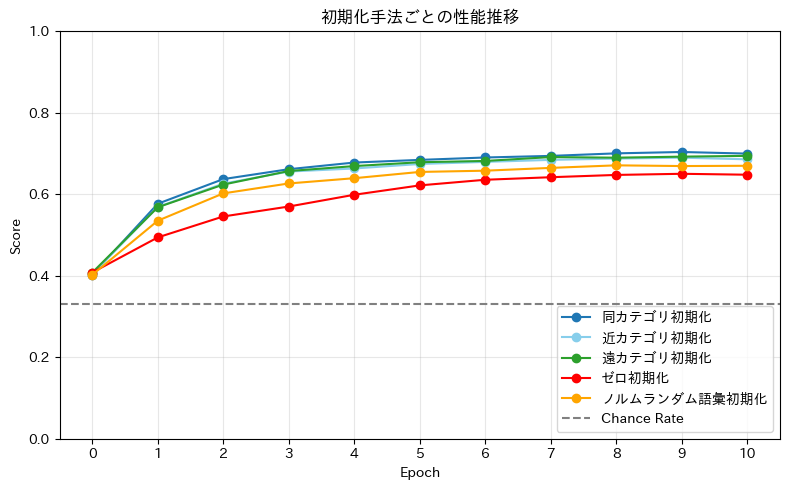

In [9]:

plt.figure(figsize=(8, 5))


# ["tab:blue", "skyblue", "tab:green", "black", "gray"]

for mean, std, label in [
    (cat_mean_accs, cat_std_accs, "同カテゴリ初期化"),
    (nearcat_mean_accs, nearcat_std_accs, "近カテゴリ初期化"),
    (farcat_mean_accs, farcat_std_accs, "遠カテゴリ初期化"),
    (zero_mean_accs, zero_std_accs, "ゼロ初期化"),
    (norm_rand_vocab_mean_accs, norm_rand_vocab_std_accs, "ノルムランダム語彙初期化"),
]:
    # print(len(epochs), len(mean))
    plt.plot(epochs, mean, marker="o", label=label, color=colors[label])
    # plt.fill_between(epochs, mean - std, mean + std, 
    #                 alpha=0.15, #0.12, 
    #                 color=colors[label], 
    #                 linewidth=2
    # )

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("初期化手法ごとの性能推移")
plt.xticks(epochs)
plt.ylim(0, 1)
# チャンスレート 3選択肢分の0.33を追加
plt.axhline(0.33, color='gray', linestyle='--', label='Chance Rate')
plt.grid(True, alpha=0.3)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

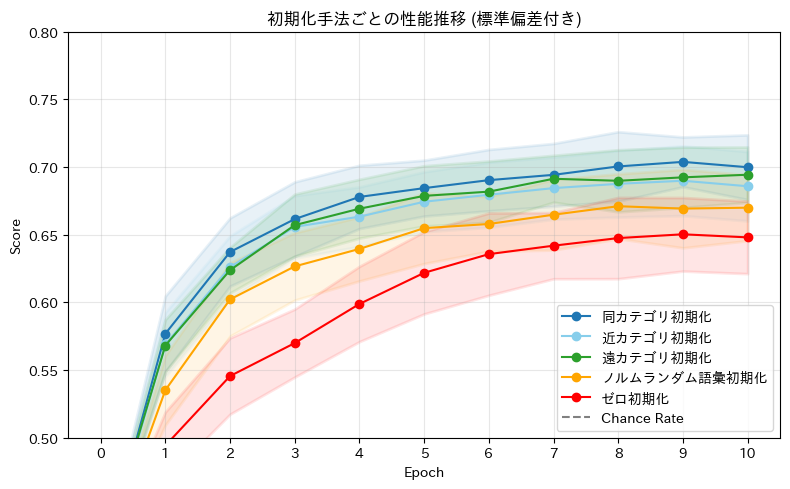

In [10]:



plt.figure(figsize=(8, 5))

for mean, std, label in [
    (cat_mean_accs, cat_std_accs, "同カテゴリ初期化"),
    (nearcat_mean_accs, nearcat_std_accs, "近カテゴリ初期化"),
    (farcat_mean_accs, farcat_std_accs, "遠カテゴリ初期化"),
    (norm_rand_vocab_mean_accs, norm_rand_vocab_std_accs, "ノルムランダム語彙初期化"),
    (zero_mean_accs, zero_std_accs, "ゼロ初期化"),
]:
    # print(len(epochs), len(mean))
    plt.plot(epochs, mean, marker="o", label=label, color=colors[label])
    plt.fill_between(epochs, mean - std, mean + std, 
                    alpha=0.1, #0.15, #0.12, 
                    color=colors[label], 
                    linewidth=2
    )

    # # 上下の境界線を点線にする (fill_betweenの境界線はデフォルトでは実線になってしまうため、改めて点線で描画する)
    # plt.plot(epochs, mean - std, linestyle="--", color=colors[label], linewidth=1.2, alpha=0.6)
    # plt.plot(epochs, mean + std, linestyle="--", color=colors[label], linewidth=1.2, alpha=0.6)
    
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("初期化手法ごとの性能推移 (標準偏差付き)")
plt.xticks(epochs)
plt.ylim(0.5, 0.8)
# チャンスレート 3選択肢分の0.33を追加
plt.axhline(0.33, color='gray', linestyle='--', label='Chance Rate')
plt.grid(True, alpha=0.3)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

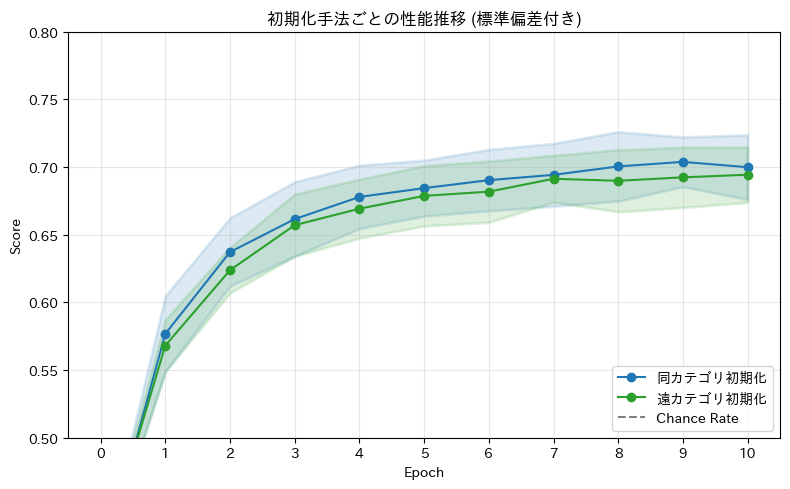

In [11]:


plt.figure(figsize=(8, 5))

for mean, std, label in [
    (cat_mean_accs, cat_std_accs, "同カテゴリ初期化"),
    # (nearcat_mean_accs, nearcat_std_accs, "近カテゴリ初期化"),
    (farcat_mean_accs, farcat_std_accs, "遠カテゴリ初期化"),
    # (norm_rand_vocab_mean_accs, norm_rand_vocab_std_accs, "ノルムランダム語彙初期化"),
    # (zero_mean_accs, zero_std_accs, "ゼロ初期化"),
]:
    # print(len(epochs), len(mean))
    plt.plot(epochs, mean, marker="o", label=label, color=colors[label])
    plt.fill_between(epochs, mean - std, mean + std, 
                    alpha=0.15, #0.12, 
                    color=colors[label], 
                    linewidth=2
    )

    # # 上下の境界線を点線にする (fill_betweenの境界線はデフォルトでは実線になってしまうため、改めて点線で描画する)
    # plt.plot(epochs, mean - std, linestyle="--", color=colors[label], linewidth=1.2, alpha=0.6)
    # plt.plot(epochs, mean + std, linestyle="--", color=colors[label], linewidth=1.2, alpha=0.6)


plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("初期化手法ごとの性能推移 (標準偏差付き)")
plt.xticks(epochs)
plt.ylim(0.5, 0.8)
# チャンスレート 3選択肢分の0.33を追加
plt.axhline(0.33, color='gray', linestyle='--', label='Chance Rate')
plt.grid(True, alpha=0.3)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

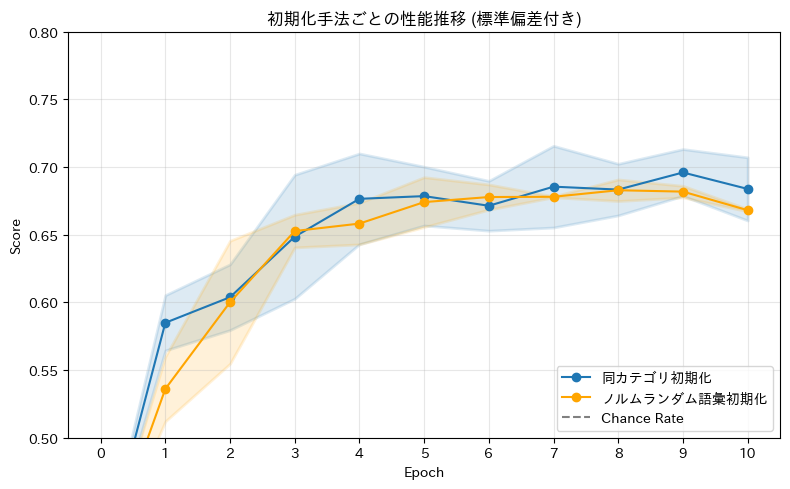

In [19]:


plt.figure(figsize=(8, 5))

for mean, std, label in [
    (cat_mean_accs, cat_std_accs, "同カテゴリ初期化"),
    # (nearcat_mean_accs, nearcat_std_accs, "近カテゴリ初期化"),
    # (farcat_mean_accs, farcat_std_accs, "遠カテゴリ初期化"),
    (norm_rand_vocab_mean_accs, norm_rand_vocab_std_accs, "ノルムランダム語彙初期化"),
    # (zero_mean_accs, zero_std_accs, "ゼロ初期化"),
]:
    # print(len(epochs), len(mean))
    plt.plot(epochs, mean, marker="o", label=label, color=colors[label])
    plt.fill_between(epochs, mean - std, mean + std, 
                    alpha=0.15, #0.12, 
                    color=colors[label], 
                    linewidth=2
    )

    # # 上下の境界線を点線にする (fill_betweenの境界線はデフォルトでは実線になってしまうため、改めて点線で描画する)
    # plt.plot(epochs, mean - std, linestyle="--", color=colors[label], linewidth=1.2, alpha=0.6)
    # plt.plot(epochs, mean + std, linestyle="--", color=colors[label], linewidth=1.2, alpha=0.6)


plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("初期化手法ごとの性能推移 (標準偏差付き)")
plt.xticks(epochs)
plt.ylim(0.5, 0.8)
# チャンスレート 3選択肢分の0.33を追加
plt.axhline(0.33, color='gray', linestyle='--', label='Chance Rate')
plt.grid(True, alpha=0.3)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [84]:
# 各手法の安定感 (stdが小さいほど安定)

same_cv = np.mean(cat_std_accs / cat_mean_accs)
# near_cv = np.mean(nearcat_std_accs / nearcat_mean_accs)
far_cv  = np.mean(farcat_std_accs / farcat_mean_accs)
norm_rand_vocab_cv = np.mean(norm_rand_vocab_std_accs / norm_rand_vocab_mean_accs)
zero_cv = np.mean(zero_std_accs / zero_mean_accs)
print("\n変動係数CV (std/mean) の平均値:")
print(f"同カテゴリ初期化: {same_cv:.4f}")
# print(f"近カテゴリ初期化: {near_cv:.4f}")
print(f"遠カテゴリ初期化: {far_cv:.4f}")
print(f"ノルムランダム語彙初期化: {norm_rand_vocab_cv:.4f}")
print(f"ゼロ初期化: {zero_cv:.4f}")


変動係数CV (std/mean) の平均値:
同カテゴリ初期化: 0.0338
遠カテゴリ初期化: 0.0321
ノルムランダム語彙初期化: 0.0349
ゼロ初期化: 0.0424


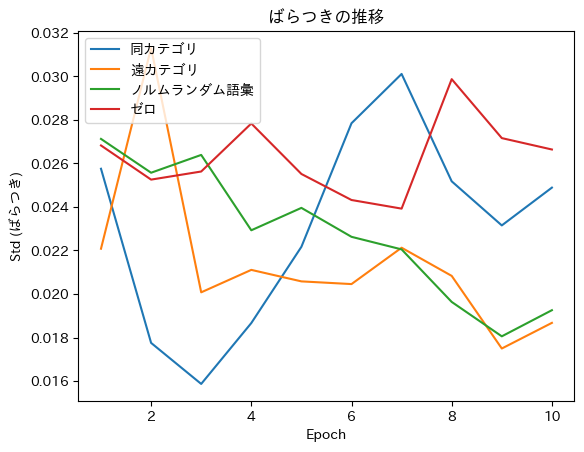

In [85]:
plt.plot(epochs, cat_std_accs, label="同カテゴリ")
# plt.plot(epochs, nearcat_std_accs, label="近カテゴリ")
plt.plot(epochs, farcat_std_accs, label="遠カテゴリ")
plt.plot(epochs, norm_rand_vocab_std_accs, label="ノルムランダム語彙")
plt.plot(epochs, zero_std_accs, label="ゼロ")

plt.xlabel("Epoch")
plt.ylabel("Std (ばらつき)")
plt.title("ばらつきの推移")
plt.legend()
plt.show()